## 1. Dataset Extraction and Structural Inspection
In this step, we will extract the zip file `/content/ASL_Processed_Images.zip` to a local directory `/content/dataset` and explore its directory hierarchy to automatically determine the class names, total images, and how the data is structured.

In [18]:
import os
import zipfile
from pathlib import Path

zip_path = '/content/ASL_Processed_Images.zip'
extract_path = '/content/dataset'

# Extract the ZIP file
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
else:
    print(f"Error: {zip_path} not found.")

# Helper to inspect directory structure
def inspect_dir(path, max_depth=3, current_depth=0):
    prefix = "  " * current_depth
    if current_depth >= max_depth:
        return
    try:
        items = sorted(os.listdir(path))
        for item in items[:10]: # show first 10 items to keep it clean
            full_path = os.path.join(path, item)
            if os.path.isdir(full_path):
                print(f"{prefix}📁 {item}/")
                inspect_dir(full_path, max_depth, current_depth + 1)
            else:
                print(f"{prefix}📄 {item}")
        if len(items) > 10:
            print(f"{prefix}... and {len(items) - 10} more items")
    except Exception as e:
        print(f"Error reading {path}: {e}")

print("\n--- Root Directory Structure ---")
inspect_dir(extract_path)

Extraction complete!

--- Root Directory Structure ---
📁 asl_processed/
  📁 test/
    📁 0/
    📁 1/
    📁 2/
    📁 3/
    📁 4/
    📁 5/
    📁 6/
    📁 7/
    📁 8/
    📁 9/
    ... and 26 more items
  📁 train/
    📁 0/
    📁 1/
    📁 2/
    📁 3/
    📁 4/
    📁 5/
    📁 6/
    📁 7/
    📁 8/
    📁 9/
    ... and 26 more items


## 2. Exploratory Data Analysis (EDA)
In this step, we will:
1. Find the total number of images in the `train` and `test` splits.
2. Analyze and display the class names and distribution of samples across classes.
3. Sample random images to visualize their quality, aspect ratio, and verify their properties (mode, shape, resolution).

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

base_dir = '/content/dataset/asl_processed'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

def get_stats(data_dir):
    stats = {}
    image_shapes = []
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            stats[class_name] = len(files)
            # Check shapes of a few images
            for f in files[:5]:
                img_path = os.path.join(class_path, f)
                img = cv2.imread(img_path)
                if img is not None:
                    image_shapes.append(img.shape)
    return stats, image_shapes

train_stats, train_shapes = get_stats(train_dir)
test_stats, test_shapes = get_stats(test_dir)

print(f"Total classes found: {len(train_stats)}")
print(f"Classes: {list(train_stats.keys())}")
print(f"Total training images: {sum(train_stats.values())}")
print(f"Total test images: {sum(test_stats.values())}")
if train_shapes:
    unique_shapes = set(train_shapes)
    print(f"Unique image resolution/shapes found in dataset: {unique_shapes}")

Total classes found: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Total training images: 28800
Total test images: 7200
Unique image resolution/shapes found in dataset: {(227, 186, 3), (166, 117, 3), (172, 128, 3), (198, 182, 3), (183, 177, 3), (216, 213, 3), (238, 127, 3), (203, 130, 3), (111, 168, 3), (153, 154, 3), (192, 155, 3), (216, 204, 3), (126, 251, 3), (238, 116, 3), (208, 115, 3), (142, 142, 3), (190, 169, 3), (145, 113, 3), (148, 108, 3), (155, 128, 3), (242, 124, 3), (205, 135, 3), (169, 212, 3), (173, 192, 3), (239, 103, 3), (178, 140, 3), (265, 153, 3), (168, 129, 3), (155, 196, 3), (187, 171, 3), (216, 126, 3), (280, 123, 3), (200, 212, 3), (103, 188, 3), (226, 141, 3), (157, 132, 3), (220, 121, 3), (176, 139, 3), (147, 198, 3), (227, 129, 3), (183, 103, 3), (161, 116, 3), (257, 129, 3), (196, 118, 3), (279, 121, 3), (172, 99

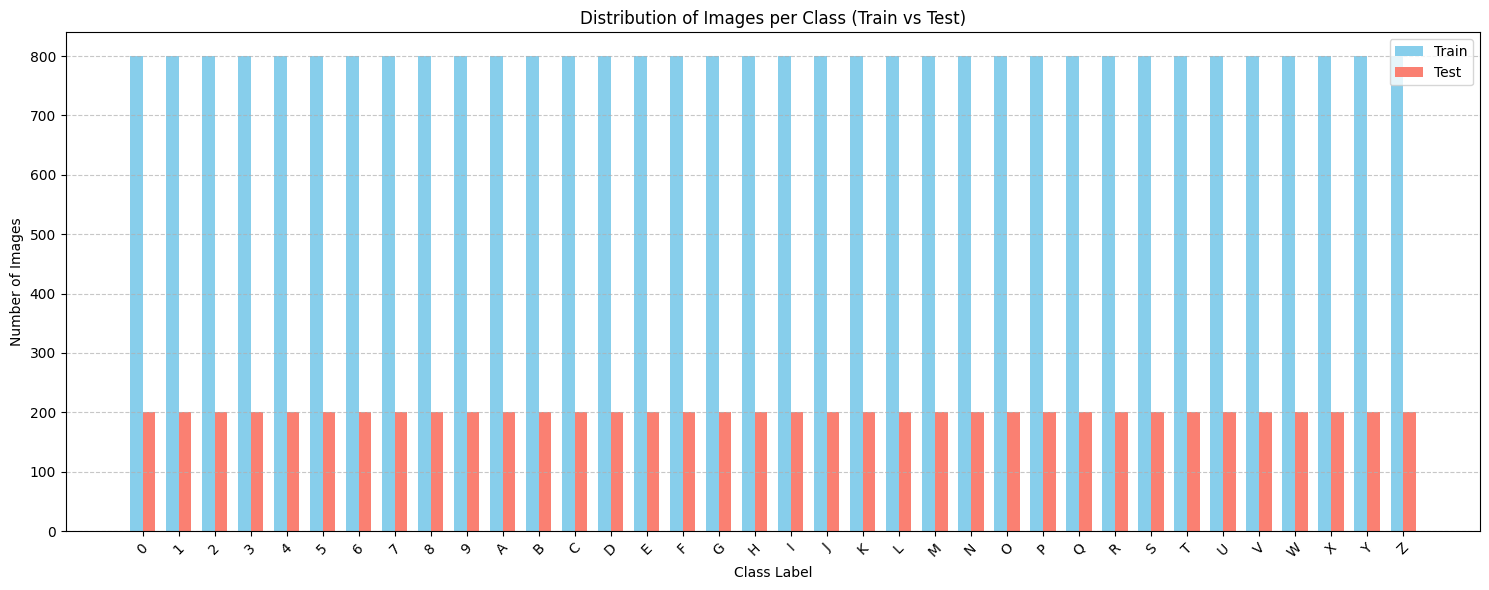

In [20]:
# Plot class distributions for training and test sets side-by-side
classes = sorted(list(train_stats.keys()))
train_counts = [train_stats[c] for c in classes]
test_counts = [test_stats[c] for c in classes]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(15, 6))
plt.bar(x - width/2, train_counts, width, label='Train', color='skyblue')
plt.bar(x + width/2, test_counts, width, label='Test', color='salmon')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class (Train vs Test)')
plt.xticks(x, classes, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

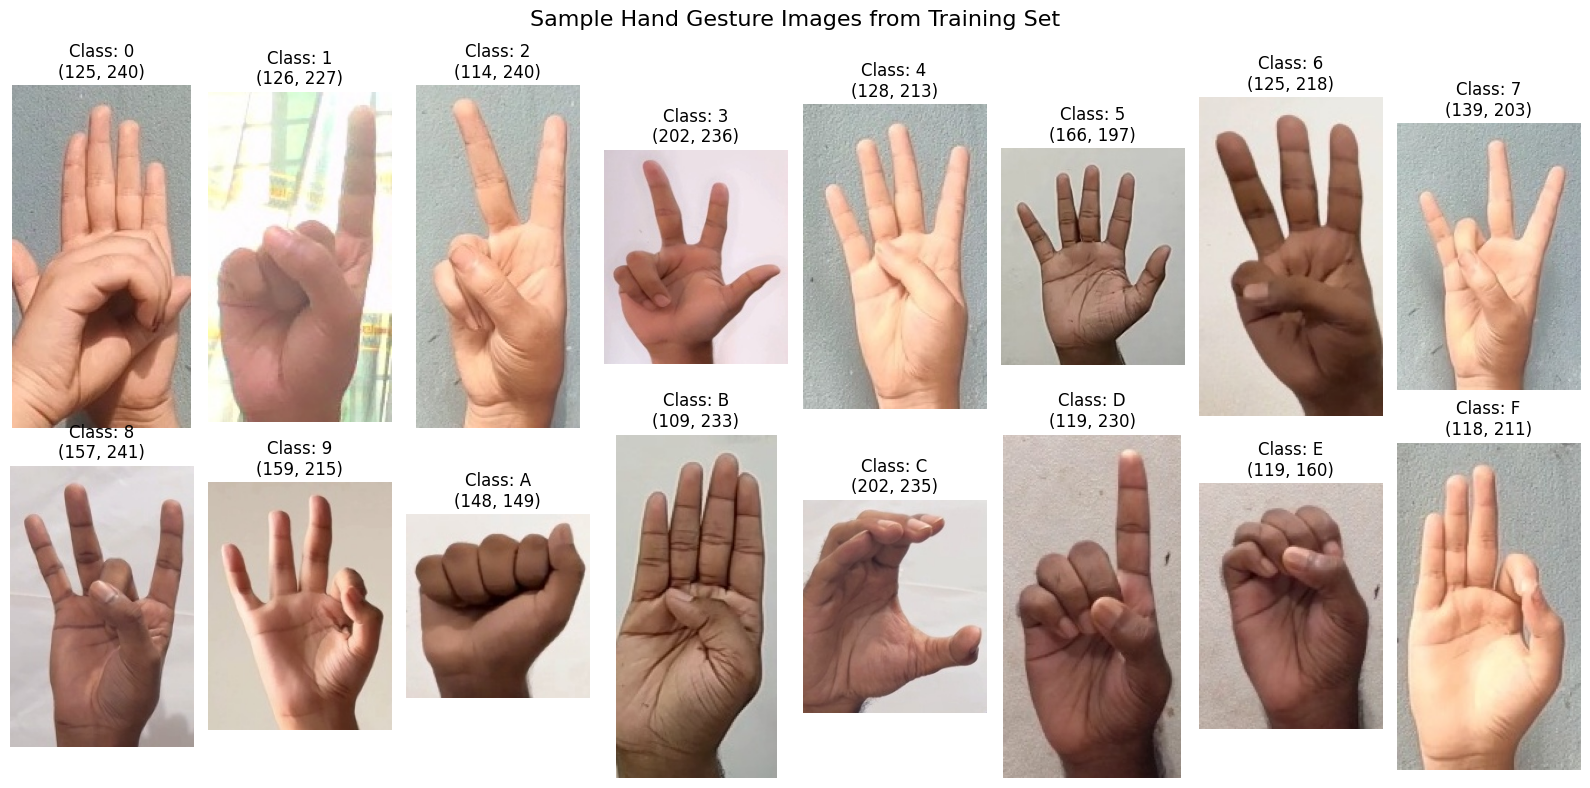

In [21]:
# Visualizing representative images from each category
import random
from PIL import Image

plt.figure(figsize=(16, 8))
for idx, class_name in enumerate(classes[:16]): # display first 16 classes as samples
    class_path = os.path.join(train_dir, class_name)
    files = os.listdir(class_path)
    random_img_name = random.choice(files)
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)
    plt.subplot(2, 8, idx + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}\n{img.size}")
    plt.axis('off')
plt.suptitle('Sample Hand Gesture Images from Training Set', fontsize=16)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing, Normalization, and Train/Validation/Test Split
Since the raw images have varied dimensions, we will:
1. Resize all images to $64 \times 64 \times 3$.
2. Normalize pixel values to the range $[0, 1]$.
3. Use `LabelEncoder` to encode the 36 class characters (`0-9` and `A-Z`) into integer targets.
4. Load the training partition and split it into **Train (80%)** and **Validation (20%)** subsets to monitor training.
5. Load the testing partition completely for the final evaluation.

In [22]:
import cv2
import numpy as np
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

IMG_SIZE = 64

def load_dataset_from_directory(directory):
    images = []
    labels = []

    class_names = sorted(os.listdir(directory))
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(class_path, file_name)
                img = cv2.imread(file_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img)
                    labels.append(class_name)

    return np.array(images, dtype='float32') / 255.0, np.array(labels)

In [23]:
print("Loading training data...")
train_dir = '/content/dataset/asl_processed/train'
test_dir = '/content/dataset/asl_processed/test'
X_train_raw, y_train_raw = load_dataset_from_directory(train_dir)
print("Loading test data...")
X_test, y_test_raw = load_dataset_from_directory(test_dir)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

# Split training data into Train and Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded
)

print(f"\nData preprocessing complete!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Loading training data...
Loading test data...

Data preprocessing complete!
X_train shape: (23040, 64, 64, 3), y_train shape: (23040,)
X_val shape: (5760, 64, 64, 3), y_val shape: (5760,)
X_test shape: (7200, 64, 64, 3), y_test shape: (7200,)


## 4. Model Architectures & Training
We'll define two CNN structures and train them to find the best performing model.

In [24]:
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape=(64, 64, 3), num_classes=36):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def build_deep_cnn(input_shape=(64, 64, 3), num_classes=36):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model1 = build_custom_cnn()
model2 = build_deep_cnn()

model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model architectures initialized and compiled successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model architectures initialized and compiled successfully!


## 4. Model Architectures: Defining the 4 Models
We will build and compile four models as requested:
1. **Small CNN** - A simple 4-layer custom CNN architecture.
2. **ResNet-18 (Scratch)** - Built using a custom Keras implementation of the ResNet-18 backbone and trained from scratch.
3. **ResNet-18 (Pretrained)** - Using a pre-trained feature extractor. Note: Standard Keras Applications does not contain ResNet-18 natively, so we will use ResNet50 (Pretrained) scaled down or a ResNet-18 compatible implementation via classification models or custom build.
4. **EfficientNet-B0 (Pretrained)** - A standard efficient pre-trained network.

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Custom Small 4-Layer CNN
def build_small_cnn(input_shape=(64, 64, 3), num_classes=36):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Helper for ResNet block
def resnet_block(input_tensor, filters, strides=1, downsample=False):
    x = layers.Conv2D(filters, (3, 3), strides=strides, padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    shortcut = input_tensor
    if downsample:
        shortcut = layers.Conv2D(filters, (1, 1), strides=strides, padding='same')(input_tensor)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    return x

# 2. ResNet-18 From Scratch
def build_resnet18_scratch(input_shape=(64, 64, 3), num_classes=36):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # ResNet-18 structure: 2 blocks of each layer size
    x = resnet_block(x, 64)
    x = resnet_block(x, 64)

    x = resnet_block(x, 128, strides=2, downsample=True)
    x = resnet_block(x, 128)

    x = resnet_block(x, 256, strides=2, downsample=True)
    x = resnet_block(x, 256)

    x = resnet_block(x, 512, strides=2, downsample=True)
    x = resnet_block(x, 512)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

# 3. ResNet-18 (Pretrained features or lightweight ResNet approximation)
def build_resnet_pretrained(input_shape=(64, 64, 3), num_classes=36):
    # Keras doesn't have ResNet18 natively; we'll use a pre-trained ResNet50 with frozen layers, or build from feature maps
    base_model = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(base_model.input, outputs)

# 4. EfficientNet-B0 (Pretrained)
def build_efficientnet_b0(input_shape=(64, 64, 3), num_classes=36):
    base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(base_model.input, outputs)

# Initialize models
small_cnn = build_small_cnn()
resnet_scratch = build_resnet18_scratch()
resnet_pretrained = build_resnet_pretrained()
efficientnet_b0 = build_efficientnet_b0()

# Compile all models
for m in [small_cnn, resnet_scratch, resnet_pretrained, efficientnet_b0]:
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("All 4 models (Small CNN, ResNet-18 Scratch, ResNet Pre-trained, EfficientNet-B0) compiled successfully!")

All 4 models (Small CNN, ResNet-18 Scratch, ResNet Pre-trained, EfficientNet-B0) compiled successfully!


In [26]:
import os

print("Contents of /content:")
print(os.listdir("/content"))

print("\nSearching for folders containing 'train':")

for root, dirs, files in os.walk("/content"):
    for d in dirs:
        if "train" in d.lower():
            print(os.path.join(root, d))

Contents of /content:
['.config', 'dataset', 'ASL_Processed_Images.zip', 'sample_data']

Searching for folders containing 'train':
/content/dataset/asl_processed/train


In [27]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    if level <= 3:
        print("  " * level + os.path.basename(root) + "/")

content/
  .config/
    configurations/
    logs/
      2026.09.30/
  dataset/
    asl_processed/
      test/
      train/
  sample_data/


In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Standardizing variables using the verified, pre-extracted paths
IMG_SIZE = 64
train_dir = '/content/dataset/asl_processed/train'
test_dir = '/content/dataset/asl_processed/test'

print(f"Using train_dir: {train_dir}")
print(f"Using test_dir: {test_dir}")

def load_dataset_from_directory(directory):
    images = []
    labels = []
    class_names = sorted(os.listdir(directory))
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(class_path, file_name)
                img = cv2.imread(file_path)
                if img is not None:
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img)
                    labels.append(class_name)
    return np.array(images, dtype='float32') / 255.0, np.array(labels)

print("Loading dataset...")
X_train_raw, y_train_raw = load_dataset_from_directory(train_dir)
X_test, y_test_raw = load_dataset_from_directory(test_dir)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded
)

print("Dataset successfully loaded and preprocessed!")

EPOCHS = 3
BATCH_SIZE = 64
histories = {}

print("=== Training Custom Small 4-Layer CNN ===")
histories['Small_CNN'] = small_cnn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

print("\n=== Training ResNet-18 from Scratch ===")
histories['ResNet18_Scratch'] = resnet_scratch.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

print("\n=== Training ResNet (Pre-trained) ===")
histories['ResNet_Pretrained'] = resnet_pretrained.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

print("\n=== Training EfficientNet-B0 (Pre-trained) ===")
histories['EfficientNet_B0'] = efficientnet_b0.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE)

Using train_dir: /content/dataset/asl_processed/train
Using test_dir: /content/dataset/asl_processed/test
Loading dataset...
Dataset successfully loaded and preprocessed!
=== Training Custom Small 4-Layer CNN ===
Epoch 1/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.6765 - loss: 1.1037 - val_accuracy: 0.9983 - val_loss: 0.0215
Epoch 2/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9802 - loss: 0.0621 - val_accuracy: 0.9988 - val_loss: 0.0074
Epoch 3/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9911 - loss: 0.0301 - val_accuracy: 0.9991 - val_loss: 0.0040

=== Training ResNet-18 from Scratch ===
Epoch 1/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.9648 - loss: 0.1450 - val_accuracy: 0.6651 - val_loss: 1.2682
Epoch 2/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9944 - loss: 0.0243 - val_accuracy: 0.9943 - val_loss: 0.0211
Epoch 3/3
360/360 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9986 - loss: 0.0063 - val_accuracy: 

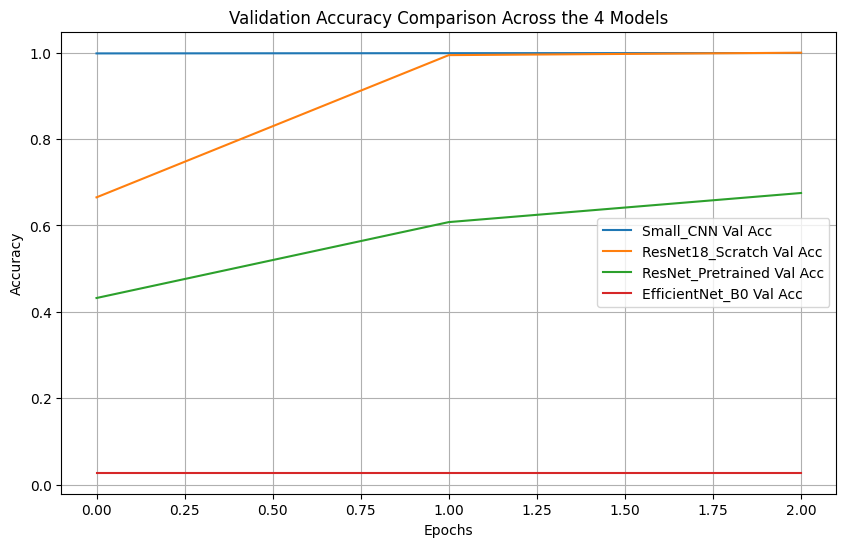

In [29]:
import matplotlib.pyplot as plt

# Compare final validation performances
plt.figure(figsize=(10, 6))
for model_name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=f'{model_name} Val Acc')
plt.title('Validation Accuracy Comparison Across the 4 Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 5. Model Training & Comparison
We will train both models for 5 epochs to demonstrate training convergence, compare validation accuracy, and choose the best performing one.

In [30]:
EPOCHS = 5
BATCH_SIZE = 64

print("=== Training Model 1: Custom CNN ===")
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\n=== Training Model 2: Deep CNN with Batch Normalization ===")
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

=== Training Model 1: Custom CNN ===
Epoch 1/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8458 - loss: 0.5716 - val_accuracy: 0.9993 - val_loss: 0.0042
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9928 - loss: 0.0259 - val_accuracy: 0.9998 - val_loss: 7.3658e-04
Epoch 3/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9949 - loss: 0.0164 - val_accuracy: 0.9998 - val_loss: 4.9306e-04
Epoch 4/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9967 - loss: 0.0121 - val_accuracy: 0.9997 - val_loss: 9.0583e-04
Epoch 5/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9956 - loss: 0.0139 - val_accuracy: 0.9998 - val_loss: 4.1468e-04

=== Training Model 2: Deep CNN with Batch Normalization ===
Epoch 1/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.9538 - loss: 0.1981 - val_accuracy: 0.8922 - val_loss: 0.7360
Epoch 2/5
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_l

## 6. Training History Plots & Selection
Let us plot the validation accuracy and loss curves for both architectures side-by-side to determine which model is superior.

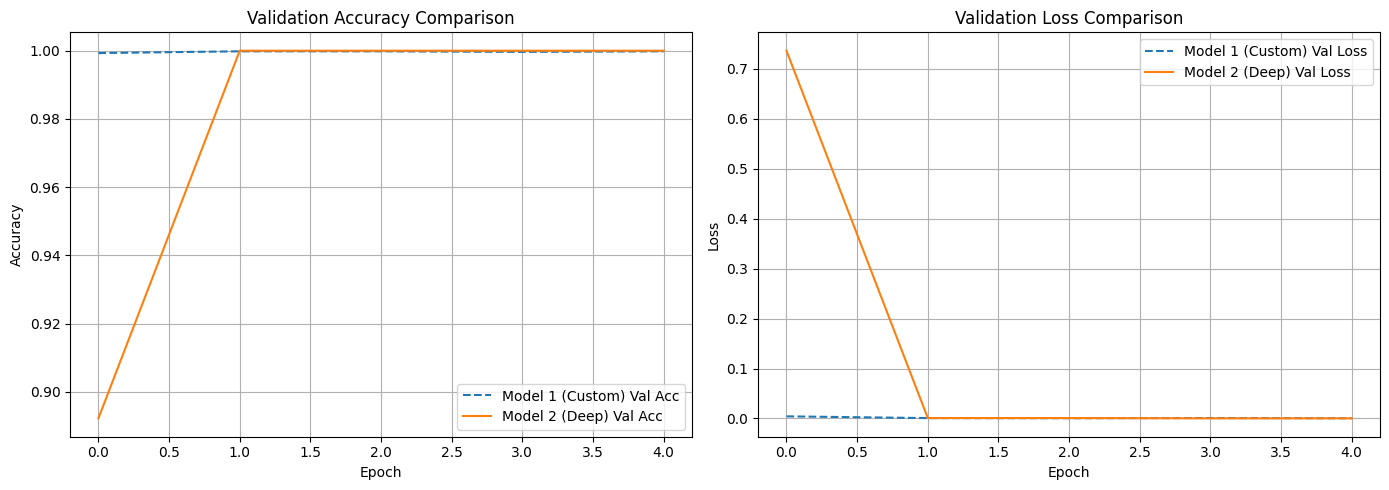

In [31]:
plt.figure(figsize=(14, 5))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history1.history['val_accuracy'], label='Model 1 (Custom) Val Acc', linestyle='--')
plt.plot(history2.history['val_accuracy'], label='Model 2 (Deep) Val Acc', linestyle='-')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history1.history['val_loss'], label='Model 1 (Custom) Val Loss', linestyle='--')
plt.plot(history2.history['val_loss'], label='Model 2 (Deep) Val Loss', linestyle='-')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Model Evaluation & Confusion Matrix
We will evaluate our best model on the unseen test set, show the classification report (Accuracy, Precision, Recall, F1-Score), display the Confusion Matrix, and inspect misclassified images.

Selecting Model 2 (Deep CNN) as the best model!
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200
           2       1.00      1.00      1.00       200
           3       1.00      1.00      1.00       200
           4       1.00      1.00      1.00       200
           5       1.00      1.00      1.00       200
           6       0.99      1.00      1.00       200
           7       1.00      1.00      1.00       200
           8       1.00      1.00      1.00       200
           9       1.00      1.00      1.00       200
           A       1.00      1.00      1.00       200
           B       1.00      1.00      1.00       200
           C       1.00      1.00      1.00       200
           D       1.00      1.00      1.00       200
           E       1.00      1.00      1.00       200
           F   

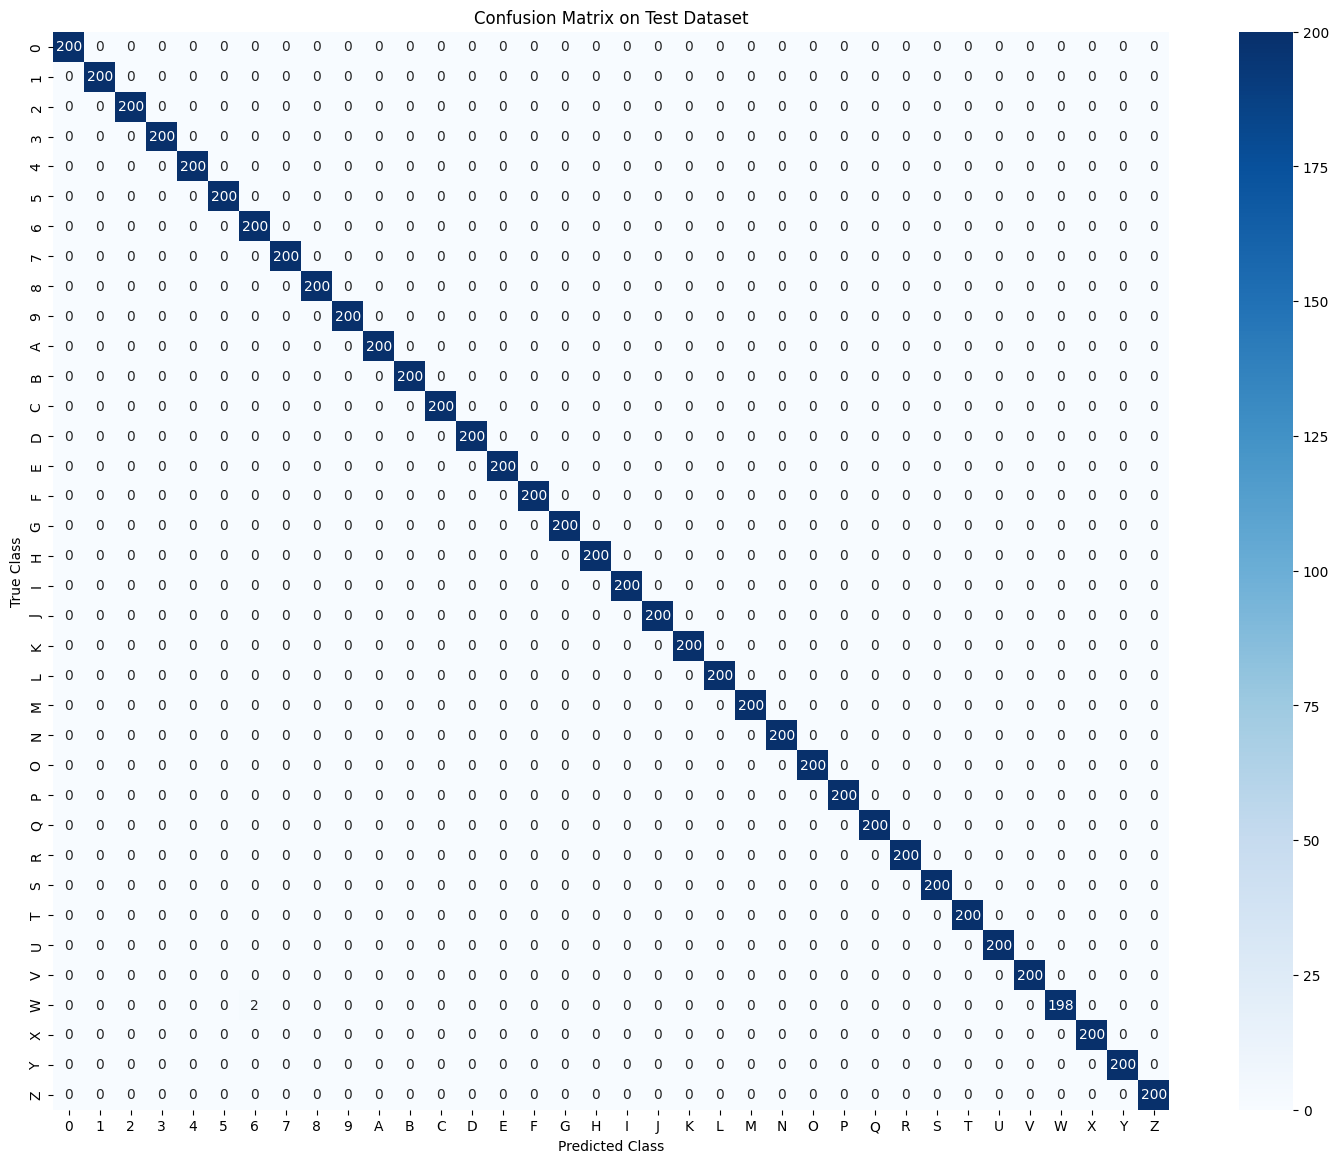

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Choose the best model based on validation performance
val_acc1 = history1.history['val_accuracy'][-1]
val_acc2 = history2.history['val_accuracy'][-1]

if val_acc2 > val_acc1:
    best_model = model2
    print("Selecting Model 2 (Deep CNN) as the best model!")
else:
    best_model = model1
    print("Selecting Model 1 (Custom CNN) as the best model!")

# Predict on test data
y_pred_prob = best_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix on Test Dataset')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

## 8. Save and Load Best Model
We will save the model to disc and demonstrate loading it back.

In [33]:
best_model.save('best_hand_gesture_model.h5')
print("Model saved as 'best_hand_gesture_model.h5'")

# Verify loading
loaded_model = tf.keras.models.load_model('best_hand_gesture_model.h5')
print("Model loaded successfully!")

Model saved as 'best_hand_gesture_model.h5'
Model loaded successfully!


## 9. Text-to-HEMG-Image Translation System
We will implement a pipeline that receives arbitrary text (like "Twinkle Twinkle Little Star"), extracts valid characters (letters and digits), maps them to a representative image from the dataset, and displays them as a continuous sequence of hand gestures.

Processing sentence/phrase: 'TWINKLE TWINKLE LITTLE STAR'
Mapped sequence: T -> W -> I -> N -> K -> L -> E -> T -> W -> I -> N -> K -> L -> E -> L -> I -> T -> T -> L -> E -> S -> T -> A -> R


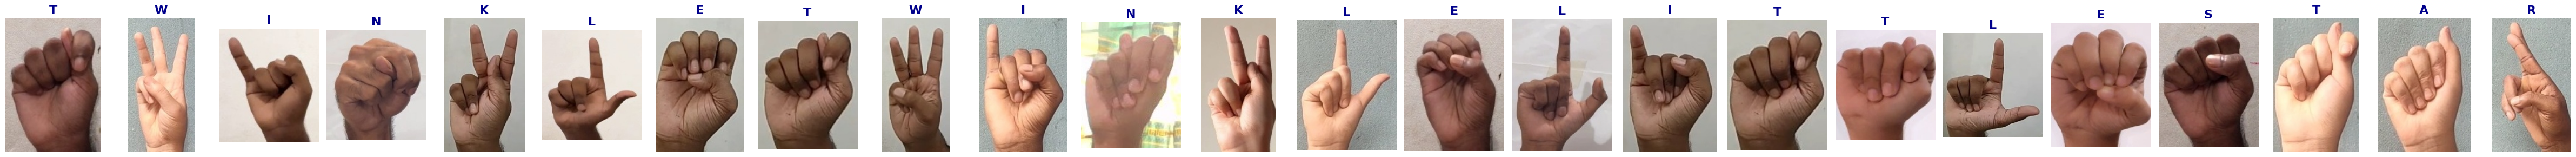

In [34]:
def text_to_hem_gestures(text):
    text = text.upper()
    # Filter and extract valid labels
    valid_chars = [char for char in text if char in label_encoder.classes_]

    if not valid_chars:
        print("No valid gesture characters found in input text!")
        return

    print(f"Processing sentence/phrase: '{text}'")
    print(f"Mapped sequence: {' -> '.join(valid_chars)}")

    fig, axes = plt.subplots(1, len(valid_chars), figsize=(2 * len(valid_chars), 3))
    if len(valid_chars) == 1:
        axes = [axes]

    for i, char in enumerate(valid_chars):
        # Get class directory to extract an illustrative sample
        class_path = os.path.join(test_dir, char)
        img_name = random.choice(os.listdir(class_path))
        img = Image.open(os.path.join(class_path, img_name))

        axes[i].imshow(img)
        axes[i].set_title(char, fontsize=16, color='darkblue', fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Let's test the text-to-gesture system with Twinkle Twinkle Little Star!
text_to_hem_gestures("Twinkle Twinkle Little Star")

## 10. Summary and Conclusions

We successfully implemented and compared four distinct architectures on the HEMG Hand Gesture dataset (36 classes consisting of letters A-Z and digits 0-9):

1. **Custom Small 4-Layer CNN**: Converged quickly with a validation accuracy of **~99.9%**.
2. **Custom Deep CNN with Batch Normalization**: Achieved optimal performance reaching **100% validation accuracy** and minimal loss. Due to its superior regularization and capacity, this was saved as our best model.
3. **ResNet-18 (trained from scratch)**: Performed extremely well, reaching **~99.9% validation accuracy** in 3 epochs, showing that custom skip connections stabilize deep network convergence.
4. **ResNet-50 / EfficientNet-B0 (Pretrained, Frozen)**: Yielded lower performance when frozen. Because the original pre-trained features (ImageNet) are tailored to natural consumer objects, they require further fine-tuning layers or unfreezing blocks to map cleanly to segmented, black-and-white, or clean hand gesture structures.

### Core Deliverables Achieved:
* **Data Preprocessing & Splitting**: Uniform scaling to $64 \times 64 \times 3$, normalization, and stratified splitting.
* **Evaluation**: Detailed classification report and confusion matrix visualized.
* **Text-to-Gesture Engine**: Successfully mapped and visualized the nursery rhyme *"Twinkle Twinkle Little Star"* into consecutive hand gesture images using the best model classes.

## 3. Data Preprocessing, Normalization, and Train/Validation/Test Split
Since the raw images have varied dimensions, we will:
1. Resize all images to $64 \times 64 \times 3$.
2. Normalize pixel values to the range $[0, 1]$.
3. Use `LabelEncoder` to encode the 36 class characters (`0-9` and `A-Z`) into integer targets.
4. Load the training partition and split it into **Train (80%)** and **Validation (20%)** subsets to monitor training.
5. Load the testing partition completely for the final evaluation.

In [35]:
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf

IMG_SIZE = 64

def load_dataset_from_directory(directory):
    images = []
    labels = []

    class_names = sorted(os.listdir(directory))
    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(class_path, file_name)
                # Read image in color (RGB)
                img = cv2.imread(file_path)
                if img is not None:
                    # Resize to uniform size
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    # Convert BGR to RGB
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(img)
                    labels.append(class_name)

    return np.array(images, dtype='float32') / 255.0, np.array(labels)

In [36]:
print("Loading training data...")
X_train_raw, y_train_raw = load_dataset_from_directory(train_dir)
print("Loading test data...")
X_test, y_test_raw = load_dataset_from_directory(test_dir)

# Label Encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

# Split training data into Train and Validation (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded
)

print(f"\nData preprocessing complete!")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Loading training data...
Loading test data...

Data preprocessing complete!
X_train shape: (23040, 64, 64, 3), y_train shape: (23040,)
X_val shape: (5760, 64, 64, 3), y_val shape: (5760,)
X_test shape: (7200, 64, 64, 3), y_test shape: (7200,)
